# 02 — Evaluate

**Fixes applied:**
- ✅ PCA removed (not used in pipeline)
- ✅ Mahalanobis removed (diagnostic only)
- ✅ Per-fruit freshness accuracy added (fresh acc / rotten acc / balanced acc per fruit)
- ✅ Empty-DASFS guards (no more IndexError / ValueError ncols=0)
- ✅ CV results loaded from disk (works in any session)


In [1]:
import os, warnings, json
warnings.filterwarnings("ignore")
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, balanced_accuracy_score)

a = "pipeline_v2/artifacts"
m = "pipeline_v2/models"
os.makedirs(a, exist_ok=True)

# ── Load models ───────────────────────────────────────────────────────────────
global_scaler = joblib.load(f"{m}/scaler.pkl")
scaler_fruit  = joblib.load(f"{m}/scaler_fruit.pkl")
scaler_fresh  = joblib.load(f"{m}/scaler_fresh.pkl")
rfe_fruit     = joblib.load(f"{m}/rfe_fruit.pkl")
rfe_fresh     = joblib.load(f"{m}/rfe_fresh.pkl")
svm_fruit     = joblib.load(f"{m}/svm_fruit.pkl")
dasfs_dict    = joblib.load(f"{m}/dasfs.pkl")
knn_bundle    = joblib.load(f"{m}/knn_dict.pkl")
knn_dict      = knn_bundle["knn_dict"]
tau_dict      = knn_bundle["tau_dict"]
top300_idx    = np.load(f"{a}/top300_cmi.npy")

# ── Load test-split artifacts ─────────────────────────────────────────────────
X_fruit_test = np.load(f"{a}/X_fruit_test.npy")
X_fresh_test = np.load(f"{a}/X_fresh_test.npy")
y_test       = np.load(f"{a}/y_test.npy")
ft_test      = np.load(f"{a}/ft_test.npy", allow_pickle=True)

FRUITS = sorted(np.unique(ft_test).tolist())
print(f"Models loaded  |  Test samples: {len(y_test)}  |  Fruits: {FRUITS}")
print(f"DASFS fruits  : {sorted(dasfs_dict.keys())}")
print(f"KNN   fruits  : {sorted(knn_dict.keys())}")


Models loaded  |  Test samples: 2759  |  Fruits: ['apple', 'banana', 'capsicum', 'carrot', 'cucumber', 'potato']
DASFS fruits  : ['apple', 'banana', 'capsicum', 'carrot', 'cucumber', 'potato']
KNN   fruits  : ['apple', 'banana', 'capsicum', 'carrot', 'cucumber', 'potato']


## Plot 1 — Accuracy vs Feature Count
*(loaded from `cv_results.json` — works across sessions)*

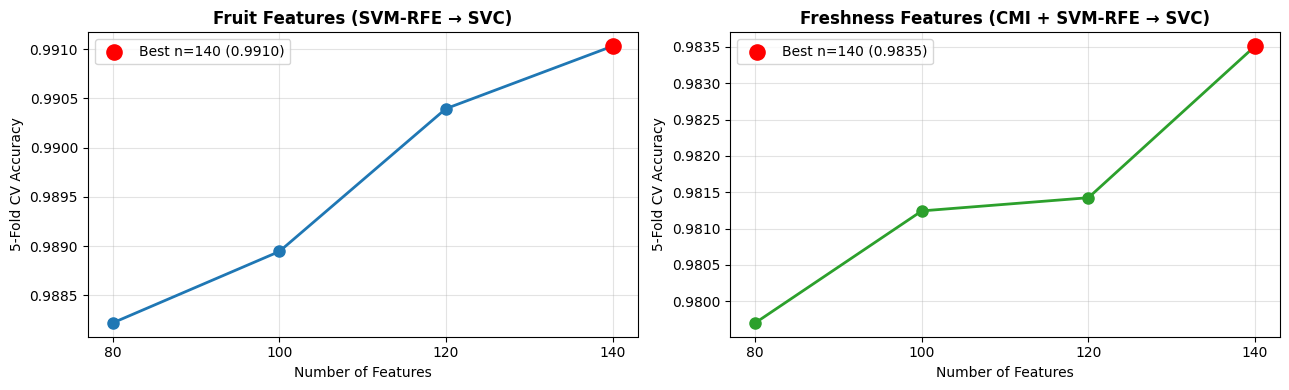

Saved -> plot_accuracy_vs_features.png


In [2]:
cv_path = f"{a}/cv_results.json"
if os.path.exists(cv_path):
    with open(cv_path) as f:
        cv = json.load(f)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for ax, key, title, color in zip(
        axes,
        ["fruit_cv_results", "fresh_cv_results"],
        ["Fruit Features (SVM-RFE → SVC)", "Freshness Features (CMI + SVM-RFE → SVC)"],
        ["#1f77b4", "#2ca02c"],
    ):
        results = cv[key]
        ns   = [r[0] for r in results]
        accs = [r[1] for r in results]
        bi   = int(np.argmax(accs))
        ax.plot(ns, accs, marker="o", color=color, linewidth=2, markersize=8)
        ax.scatter([ns[bi]], [accs[bi]], color="red", zorder=5, s=120,
                   label=f"Best n={ns[bi]} ({accs[bi]:.4f})")
        ax.set_xlabel("Number of Features"); ax.set_ylabel("5-Fold CV Accuracy")
        ax.set_title(title, fontweight="bold"); ax.set_xticks(ns)
        ax.legend(); ax.grid(alpha=0.35)
    plt.tight_layout()
    plt.savefig(f"{a}/plot_accuracy_vs_features.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved -> plot_accuracy_vs_features.png")
else:
    print("cv_results.json not found — add PATCH CELL B to 01_train.ipynb and re-run.")


## Plot 2 — Fruit Classifier Confusion Matrix

Fruit accuracy: 0.9920

              precision    recall  f1-score   support

       apple       0.99      1.00      0.99       897
      banana       1.00      1.00      1.00       940
    capsicum       1.00      0.99      0.99       228
      carrot       0.99      1.00      0.99       218
    cucumber       0.99      0.96      0.98       182
      potato       0.98      0.98      0.98       294

    accuracy                           0.99      2759
   macro avg       0.99      0.99      0.99      2759
weighted avg       0.99      0.99      0.99      2759



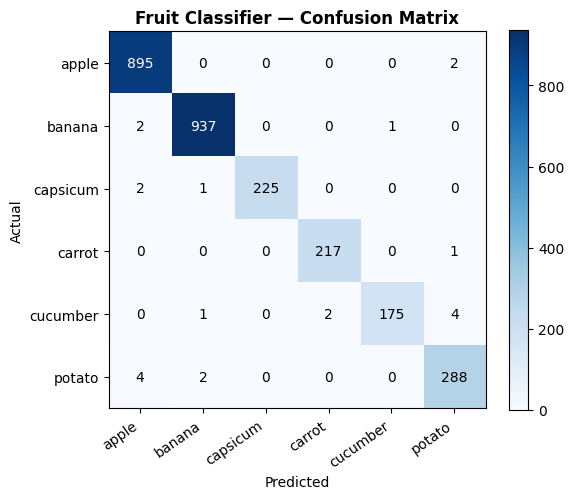

Saved -> plot_confusion_fruit.png


In [3]:
pred_fruit = svm_fruit.predict(X_fruit_test)
print(f"Fruit accuracy: {accuracy_score(ft_test, pred_fruit):.4f}\n")
print(classification_report(ft_test, pred_fruit))

cm = confusion_matrix(ft_test, pred_fruit, labels=FRUITS)
fig, ax = plt.subplots(figsize=(max(6, len(FRUITS)), max(5, len(FRUITS) - 1)))
im = ax.imshow(cm, cmap="Blues"); plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(FRUITS))); ax.set_xticklabels(FRUITS, rotation=35, ha="right")
ax.set_yticks(range(len(FRUITS))); ax.set_yticklabels(FRUITS)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Fruit Classifier — Confusion Matrix", fontweight="bold")
for i in range(len(FRUITS)):
    for j in range(len(FRUITS)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() * 0.5 else "black")
plt.tight_layout()
plt.savefig(f"{a}/plot_confusion_fruit.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved -> plot_confusion_fruit.png")


## Plot 3 — Per-Fruit Freshness Accuracy

For each fruit: **fresh accuracy**, **rotten accuracy**, **balanced accuracy**.

Uses ground-truth fruit labels (not predicted) — fruit misclassification
does not pollute this metric.  
DASFS threshold = 0.50 (score > 0.5 → predicted fresh).


In [4]:
def _dasfs_score(x_vec, fruit):
    if fruit not in dasfs_dict:
        return None, None
    d    = dasfs_dict[fruit]
    proj = float(x_vec @ d["axis"])
    p_f, p_r, sp = d["p_fresh"], d["p_rotten"], d["spread"]
    score = float(np.clip((p_r - proj) / (p_r - p_f + 1e-8), 0.0, 1.0))
    mid   = (p_f + p_r) / 2.0
    conf  = float(np.clip(
        1.0 - np.exp(-((proj - mid) ** 2) / (2.0 * sp ** 2 + 1e-8)), 0.0, 1.0))
    return score, conf


print("=" * 65)
print("Per-Fruit Freshness Accuracy  (DASFS threshold = 0.50)")
print("=" * 65)
print(f"{'Fruit':15s}  {'Fresh acc':>10}  {'Rotten acc':>10}  "
      f"{'Balanced':>10}  {'N_fresh':>8}  {'N_rotten':>9}")
print("-" * 65)

rows = []
for fruit in FRUITS:
    if fruit not in dasfs_dict:
        print(f"  {fruit:13s}  [SKIP — no DASFS anchors]"); continue
    mask = ft_test == fruit
    Xf   = X_fresh_test[mask]
    yt   = y_test[mask]
    nf   = (yt == 0).sum(); nr = (yt == 1).sum()
    if nf == 0 or nr == 0:
        print(f"  {fruit:13s}  [SKIP — missing fresh or rotten in test set]"); continue

    scores = np.array([_dasfs_score(Xf[i], fruit)[0] for i in range(len(Xf))])
    pred   = (scores > 0.5).astype(int)   # 1 = predicted fresh
    true_f = (yt == 0).astype(int)        # 1 = actually fresh

    # fresh accuracy = among actually-fresh samples, how many predicted fresh
    acc_f  = accuracy_score(true_f[yt == 0], pred[yt == 0])
    # rotten accuracy = among actually-rotten samples, how many predicted rotten
    acc_r  = accuracy_score(1 - true_f[yt == 1], 1 - pred[yt == 1])
    bal    = (acc_f + acc_r) / 2.0

    rows.append((fruit, acc_f, acc_r, bal, int(nf), int(nr)))
    print(f"  {fruit:13s}  {acc_f:>10.3f}  {acc_r:>10.3f}  "
          f"{bal:>10.3f}  {nf:>8d}  {nr:>9d}")

print("-" * 65)
if rows:
    avg = float(np.mean([r[3] for r in rows]))
    print(f"  {'Mean':13s}  {'':>10}  {'':>10}  {avg:>10.3f}")
else:
    print("  No data — re-run 01_train with PATCH A applied.")


Per-Fruit Freshness Accuracy  (DASFS threshold = 0.50)
Fruit             Fresh acc  Rotten acc    Balanced   N_fresh   N_rotten
-----------------------------------------------------------------
  apple               0.941       0.874       0.907       390        507
  banana              0.941       0.985       0.963       421        519
  capsicum            0.973       0.976       0.974       187         41
  carrot              0.891       0.960       0.925       119         99
  cucumber            0.920       0.874       0.897        87         95
  potato              0.802       0.816       0.809       131        163
-----------------------------------------------------------------
  Mean                                        0.912


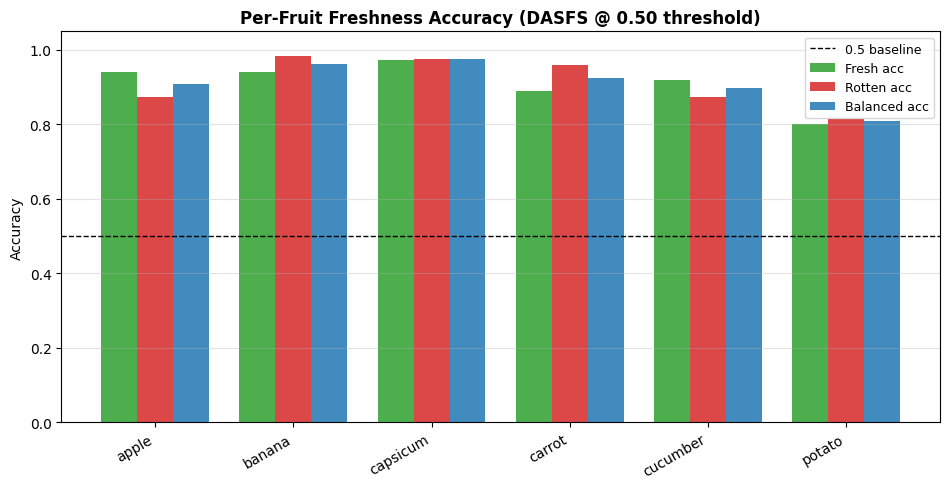

Saved -> plot_per_fruit_freshness_acc.png


In [5]:
# ── Bar chart: per-fruit freshness accuracy ──────────────────────────────────
if rows:
    fruits_d = [r[0] for r in rows]
    x = np.arange(len(fruits_d)); w = 0.26
    fig, ax = plt.subplots(figsize=(max(8, len(fruits_d) * 1.6), 5))
    ax.bar(x - w, [r[1] for r in rows], w, label="Fresh acc",    color="#2ca02c", alpha=0.85)
    ax.bar(x,     [r[2] for r in rows], w, label="Rotten acc",   color="#d62728", alpha=0.85)
    ax.bar(x + w, [r[3] for r in rows], w, label="Balanced acc", color="#1f77b4", alpha=0.85)
    ax.axhline(0.5, color="black", ls="--", lw=1, label="0.5 baseline")
    ax.set_xticks(x); ax.set_xticklabels(fruits_d, rotation=30, ha="right")
    ax.set_ylim(0, 1.05); ax.set_ylabel("Accuracy")
    ax.set_title("Per-Fruit Freshness Accuracy (DASFS @ 0.50 threshold)",
                 fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    plt.savefig(f"{a}/plot_per_fruit_freshness_acc.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved -> plot_per_fruit_freshness_acc.png")
else:
    print("No rows to plot.")


## Plot 4 — DASFS Overall Freshness Accuracy

In [6]:
scores_list = []
for i in range(len(X_fresh_test)):
    f    = ft_test[i]
    s, c = _dasfs_score(X_fresh_test[i], f)
    if s is None: continue
    scores_list.append((s, c, int(y_test[i])))

if len(scores_list) == 0:
    print("WARNING: scores_list is empty.")
    print("  -> dasfs_dict is empty. Apply PATCH A in 01_train and re-run training.")
else:
    arr  = np.array(scores_list)               # (N, 3)
    pred = (arr[:, 0] > 0.5).astype(int)       # 1 = predicted fresh
    true = (arr[:, 2] == 0).astype(int)        # 1 = actually fresh
    n_skip = len(X_fresh_test) - len(scores_list)
    print(f"Evaluated {len(arr)}/{len(X_fresh_test)} samples ({n_skip} skipped — fruit not in DASFS)")
    print(f"Accuracy : {accuracy_score(true, pred):.4f}")
    print(f"Balanced : {balanced_accuracy_score(true, pred):.4f}\n")
    print(classification_report(true, pred, target_names=["Rotten", "Fresh"]))


Evaluated 2759/2759 samples (0 skipped — fruit not in DASFS)
Accuracy : 0.9210
Balanced : 0.9211

              precision    recall  f1-score   support

      Rotten       0.93      0.92      0.92      1424
       Fresh       0.91      0.93      0.92      1335

    accuracy                           0.92      2759
   macro avg       0.92      0.92      0.92      2759
weighted avg       0.92      0.92      0.92      2759



## Plot 5 — KNN Distance Distribution per Fruit

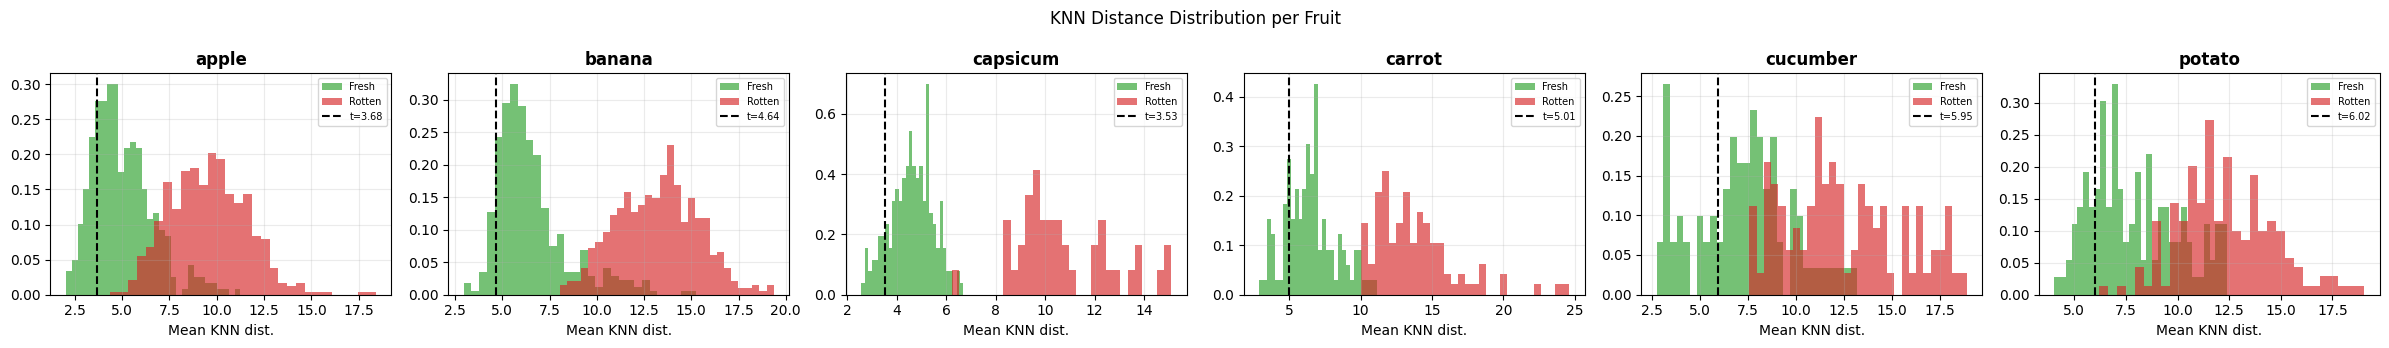

Saved -> plot_knn_dist.png


In [7]:
valid_knn = [f for f in FRUITS if f in knn_dict]
if not valid_knn:
    print("No KNN models found.")
else:
    fig, axes = plt.subplots(1, len(valid_knn), figsize=(4 * len(valid_knn), 3.5))
    if len(valid_knn) == 1: axes = [axes]
    for ax, fruit in zip(axes, valid_knn):
        mask = ft_test == fruit
        if mask.sum() == 0: ax.set_title(fruit); continue
        dists, _ = knn_dict[fruit].kneighbors(X_fresh_test[mask])
        kdist = dists.mean(axis=1); yfr = y_test[mask]
        ax.hist(kdist[yfr == 0], bins=30, alpha=0.65, color="#2ca02c",
                label="Fresh",  density=True)
        ax.hist(kdist[yfr == 1], bins=30, alpha=0.65, color="#d62728",
                label="Rotten", density=True)
        ax.axvline(tau_dict[fruit], color="black", ls="--", lw=1.5,
                   label=f"t={tau_dict[fruit]:.2f}")
        ax.set_title(fruit, fontweight="bold")
        ax.set_xlabel("Mean KNN dist.")
        ax.legend(fontsize=7); ax.grid(alpha=0.25)
    plt.suptitle("KNN Distance Distribution per Fruit")
    plt.tight_layout()
    plt.savefig(f"{a}/plot_knn_dist.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved -> plot_knn_dist.png")


## Plot 6 — DASFS Projection Distribution per Fruit

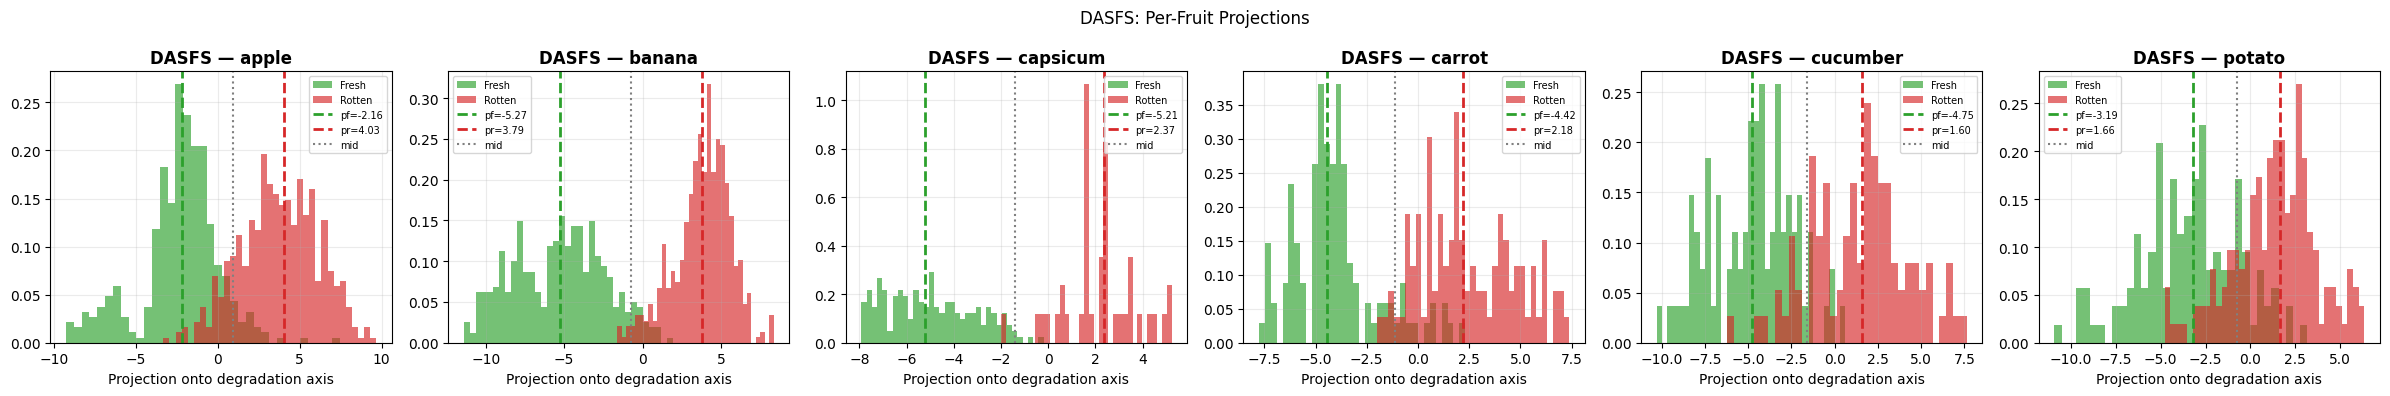

Saved -> plot_dasfs_projections.png


In [8]:
valid_dasfs = [f for f in FRUITS if f in dasfs_dict]
if not valid_dasfs:
    print("dasfs_dict is empty — apply PATCH A and re-run 01_train.")
else:
    fig, axes = plt.subplots(1, len(valid_dasfs), figsize=(4 * len(valid_dasfs), 4))
    if len(valid_dasfs) == 1: axes = [axes]
    for ax, fruit in zip(axes, valid_dasfs):
        d    = dasfs_dict[fruit]
        mask = ft_test == fruit
        if mask.sum() == 0: ax.set_title(fruit); continue
        proj = X_fresh_test[mask] @ d["axis"]
        yfr  = y_test[mask]
        ax.hist(proj[yfr == 0], bins=35, alpha=0.65, color="#2ca02c",
                label="Fresh",  density=True)
        ax.hist(proj[yfr == 1], bins=35, alpha=0.65, color="#d62728",
                label="Rotten", density=True)
        ax.axvline(d["p_fresh"],  color="#2ca02c", ls="--", lw=2,
                   label=f'pf={d["p_fresh"]:.2f}')
        ax.axvline(d["p_rotten"], color="#d62728", ls="--", lw=2,
                   label=f'pr={d["p_rotten"]:.2f}')
        ax.axvline((d["p_fresh"] + d["p_rotten"]) / 2,
                   color="grey", ls=":", lw=1.5, label="mid")
        ax.set_title(f"DASFS — {fruit}", fontweight="bold")
        ax.set_xlabel("Projection onto degradation axis")
        ax.legend(fontsize=7); ax.grid(alpha=0.25)
    plt.suptitle("DASFS: Per-Fruit Projections")
    plt.tight_layout()
    plt.savefig(f"{a}/plot_dasfs_projections.png", dpi=150, bbox_inches="tight")
    plt.show(); print("Saved -> plot_dasfs_projections.png")


### ROC Curves per Fruit

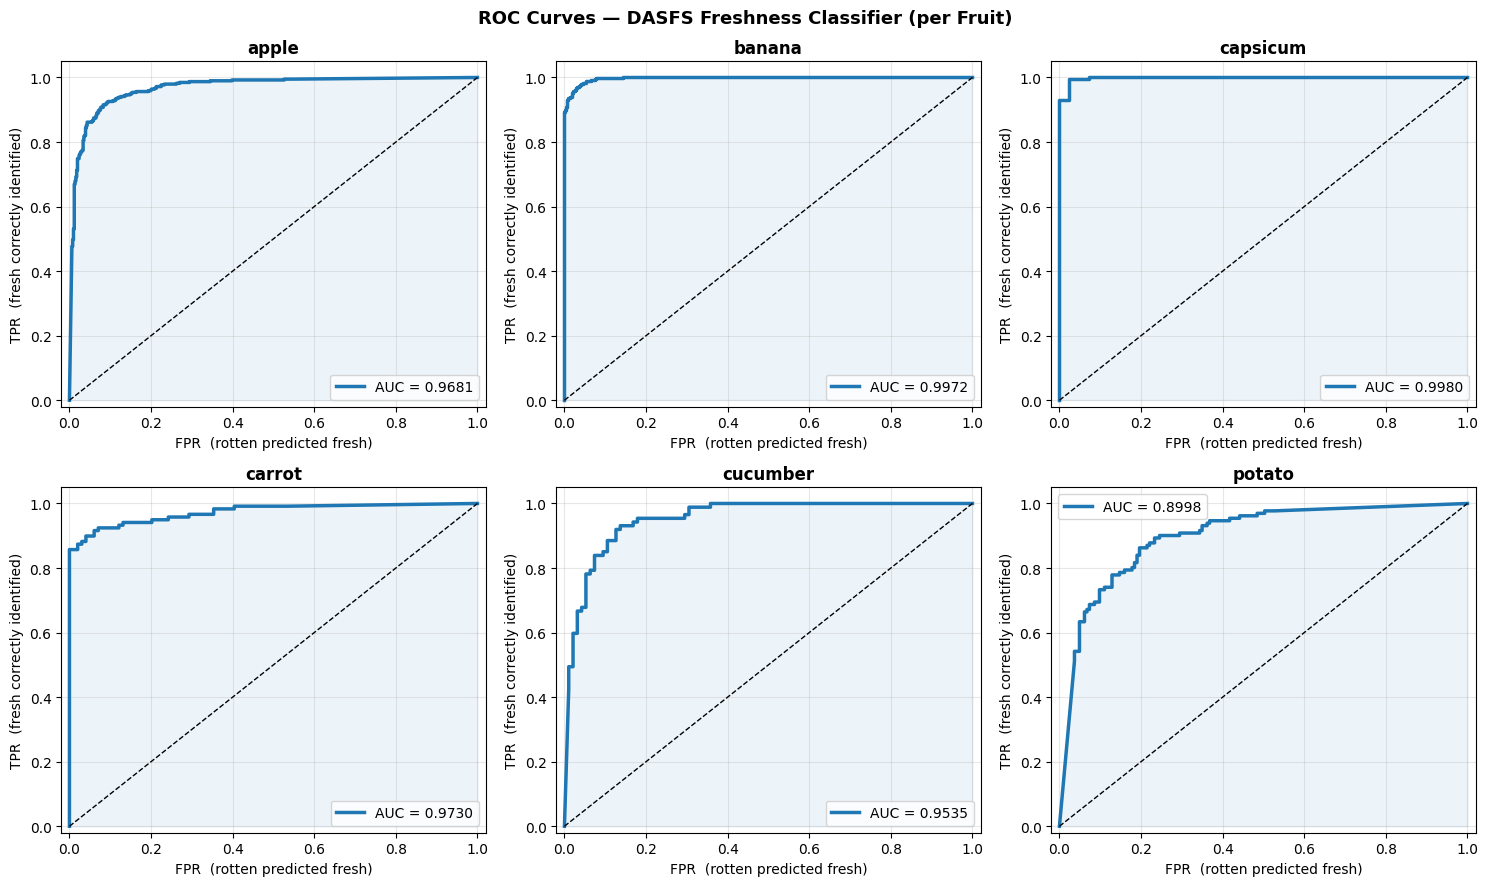

Saved -> plot_roc_per_fruit.png


In [9]:
# ── Plot 7 — ROC Curves per Fruit ────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

valid_dasfs = [f for f in FRUITS if f in dasfs_dict]
ncols = 3; nrows = (len(valid_dasfs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.array(axes).flatten()

for idx, fruit in enumerate(valid_dasfs):
    mask   = ft_test == fruit
    Xf     = X_fresh_test[mask]; yt = y_test[mask]
    scores = np.array([_dasfs_score(Xf[i], fruit)[0] for i in range(len(Xf))])
    true_f = (yt == 0).astype(int)                     # 1 = fresh (positive)
    fpr, tpr, _ = roc_curve(true_f, scores)
    roc_auc     = auc(fpr, tpr)
    axes[idx].plot(fpr, tpr, lw=2.5, color="#1f77b4", label=f"AUC = {roc_auc:.4f}")
    axes[idx].fill_between(fpr, tpr, alpha=0.08, color="#1f77b4")
    axes[idx].plot([0,1],[0,1],"k--",lw=1)
    axes[idx].set_title(fruit, fontweight="bold")
    axes[idx].set_xlabel("FPR  (rotten predicted fresh)")
    axes[idx].set_ylabel("TPR  (fresh correctly identified)")
    axes[idx].legend(fontsize=10); axes[idx].grid(alpha=0.3)
    axes[idx].set_xlim(-0.02, 1.02); axes[idx].set_ylim(-0.02, 1.05)

for i in range(len(valid_dasfs), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("ROC Curves — DASFS Freshness Classifier (per Fruit)",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{a}/plot_roc_per_fruit.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved -> plot_roc_per_fruit.png")

### Threshold Sweep (find optimal DASFS decision boundary)


Optimal thresholds vs current 0.50:
  apple            optimal=0.58  balanced_acc=0.9163  ← shift +0.08
  banana           optimal=0.40  balanced_acc=0.9691  ← shift -0.10
  capsicum         optimal=0.37  balanced_acc=0.9851  ← shift -0.13
  carrot           optimal=0.54  balanced_acc=0.9269  ← shift +0.04
  cucumber         optimal=0.49  balanced_acc=0.8966  ← same
  potato           optimal=0.42  balanced_acc=0.8331  ← shift -0.08


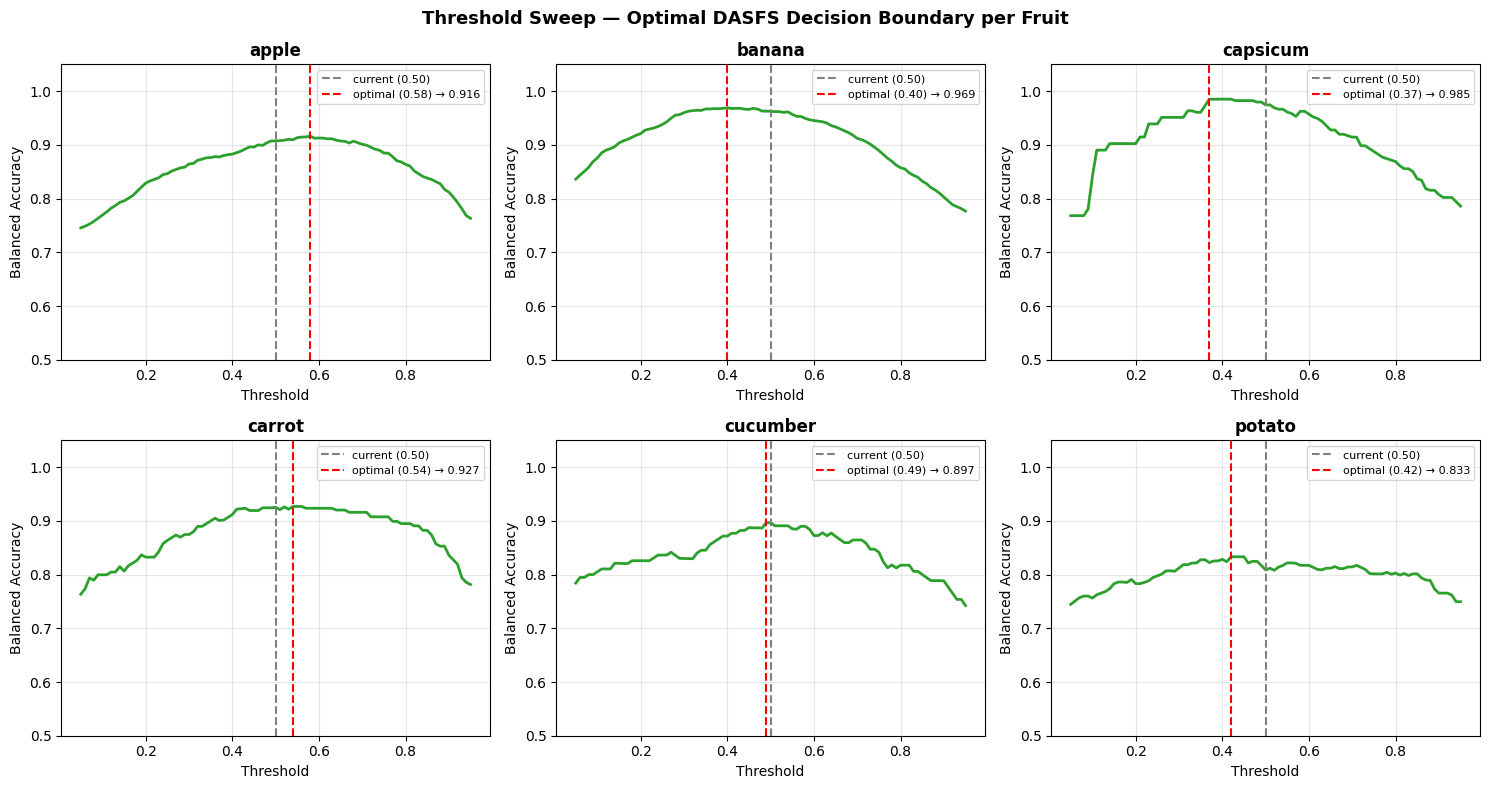

Saved -> plot_threshold_sweep.png


In [10]:
# ── Plot 8 — Threshold Sweep ──────────────────────────────────────────────────
thresholds  = np.linspace(0.05, 0.95, 91)
valid_dasfs = [f for f in FRUITS if f in dasfs_dict]
ncols = 3; nrows = (len(valid_dasfs) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

opt_thresholds = {}
for idx, fruit in enumerate(valid_dasfs):
    mask   = ft_test == fruit
    Xf     = X_fresh_test[mask]; yt = y_test[mask]
    scores = np.array([_dasfs_score(Xf[i], fruit)[0] for i in range(len(Xf))])
    true_f = (yt == 0).astype(int)
    bal_accs = [balanced_accuracy_score(true_f, (scores > t).astype(int))
                for t in thresholds]
    best_idx = int(np.argmax(bal_accs))
    best_t   = thresholds[best_idx]; best_a = bal_accs[best_idx]
    opt_thresholds[fruit] = (best_t, best_a)

    axes[idx].plot(thresholds, bal_accs, lw=2, color="#2ca02c")
    axes[idx].axvline(0.50, color="gray", ls="--", lw=1.5, label="current (0.50)")
    axes[idx].axvline(best_t, color="red", ls="--", lw=1.5,
                      label=f"optimal ({best_t:.2f}) → {best_a:.3f}")
    axes[idx].set_title(fruit, fontweight="bold")
    axes[idx].set_xlabel("Threshold"); axes[idx].set_ylabel("Balanced Accuracy")
    axes[idx].legend(fontsize=8); axes[idx].grid(alpha=0.3)
    axes[idx].set_ylim(0.5, 1.05)

for i in range(len(valid_dasfs), len(axes)):
    axes[i].set_visible(False)

print("\nOptimal thresholds vs current 0.50:")
for f, (t, acc) in opt_thresholds.items():
    diff = t - 0.50
    tag  = "  ← same" if abs(diff) < 0.03 else f"  ← shift {diff:+.2f}"
    print(f"  {f:15s}  optimal={t:.2f}  balanced_acc={acc:.4f}{tag}")

plt.suptitle("Threshold Sweep — Optimal DASFS Decision Boundary per Fruit",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{a}/plot_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved -> plot_threshold_sweep.png")

### Score Distribution + Score vs Confidence

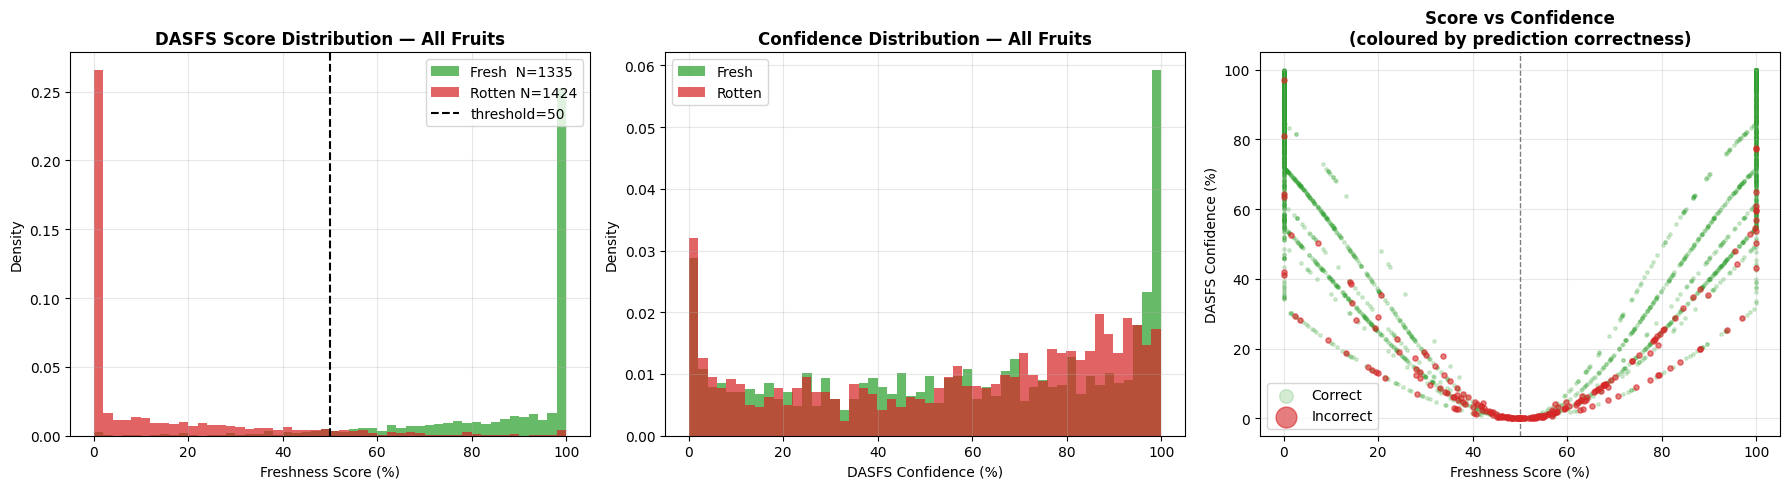

Saved -> plot_score_confidence.png
Correct: 2541 / 2759  (92.10%)
Misclassified near threshold (score 40–60%): 92


In [11]:
# ── Plot 9 — Score Distribution + Score vs Confidence ────────────────────────
if len(scores_list) == 0:
    print("scores_list is empty — run the Plot 4 cell first.")
else:
    arr         = np.array(scores_list)           # (N,3): score, conf, label
    fresh_mask  = arr[:, 2] == 0
    rotten_mask = arr[:, 2] == 1
    fs = arr[fresh_mask,  0] * 100;  rs = arr[rotten_mask, 0] * 100
    fc = arr[fresh_mask,  1] * 100;  rc = arr[rotten_mask, 1] * 100
    preds   = (arr[:, 0] > 0.5).astype(int)
    true_f  = (arr[:, 2] == 0).astype(int)
    correct = (preds == true_f)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Score histogram
    axes[0].hist(fs, bins=50, alpha=0.72, color="#2ca02c",
                 label=f"Fresh  N={len(fs)}", density=True)
    axes[0].hist(rs, bins=50, alpha=0.72, color="#d62728",
                 label=f"Rotten N={len(rs)}", density=True)
    axes[0].axvline(50, color="black", ls="--", lw=1.5, label="threshold=50")
    axes[0].set_xlabel("Freshness Score (%)"); axes[0].set_ylabel("Density")
    axes[0].set_title("DASFS Score Distribution — All Fruits", fontweight="bold")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Confidence histogram
    axes[1].hist(fc, bins=50, alpha=0.72, color="#2ca02c", label="Fresh",  density=True)
    axes[1].hist(rc, bins=50, alpha=0.72, color="#d62728", label="Rotten", density=True)
    axes[1].set_xlabel("DASFS Confidence (%)"); axes[1].set_ylabel("Density")
    axes[1].set_title("Confidence Distribution — All Fruits", fontweight="bold")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # Score vs Confidence coloured by correctness
    axes[2].scatter(arr[correct,  0]*100, arr[correct,  1]*100,
                    alpha=0.2, s=6,  color="#2ca02c", label="Correct")
    axes[2].scatter(arr[~correct, 0]*100, arr[~correct, 1]*100,
                    alpha=0.6, s=14, color="#d62728", label="Incorrect", zorder=3)
    axes[2].axvline(50, color="black", ls="--", lw=1, alpha=0.5)
    axes[2].set_xlabel("Freshness Score (%)")
    axes[2].set_ylabel("DASFS Confidence (%)")
    axes[2].set_title("Score vs Confidence\n(coloured by prediction correctness)",
                      fontweight="bold")
    axes[2].legend(markerscale=4); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{a}/plot_score_confidence.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved -> plot_score_confidence.png")
    print(f"Correct: {correct.sum()} / {len(correct)}  ({correct.mean()*100:.2f}%)")
    print(f"Misclassified near threshold (score 40–60%): "
          f"{((arr[:,0]*100 > 40) & (arr[:,0]*100 < 60) & ~correct).sum()}")

###  Feature Breakdown: EfficientNet vs Handcrafted groups

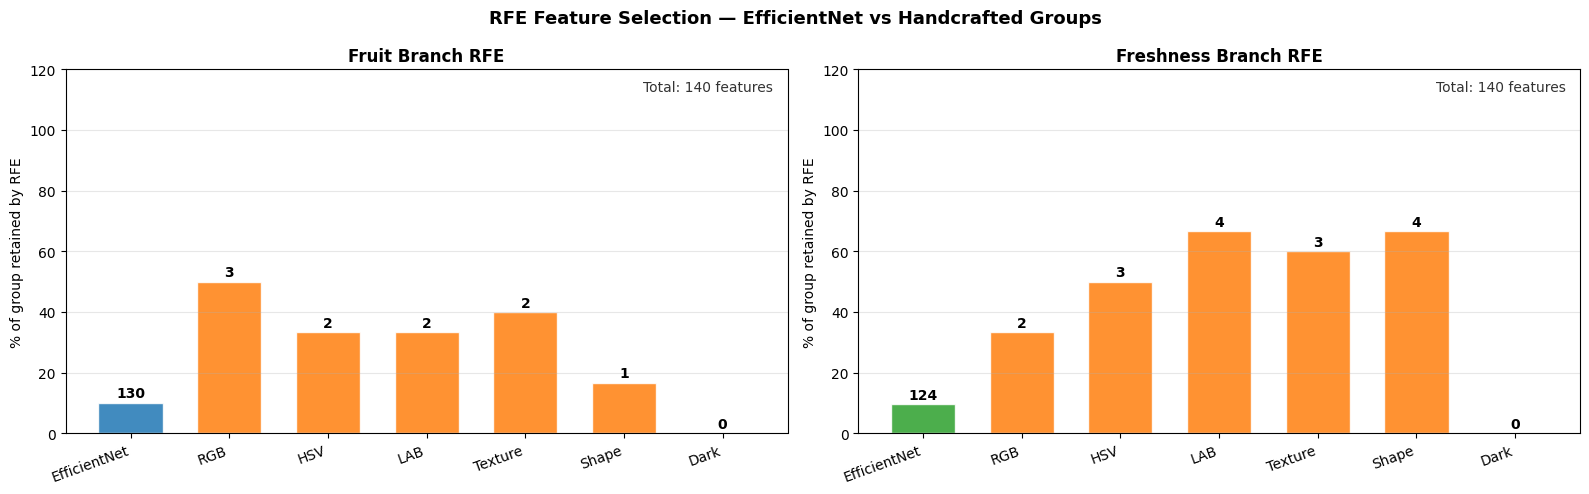

Saved -> plot_feature_breakdown.png


In [12]:
# ── Plot 10 — RFE Feature Selection Breakdown ─────────────────────────────────
# Reconstruct freshness branch original-space indices
fresh_final_idx_local = top300_idx[np.where(rfe_fresh.support_)[0]]

HC_START  = 1280
HC_GROUPS = {
    "RGB":     (HC_START,      HC_START + 6),
    "HSV":     (HC_START + 6,  HC_START + 12),
    "LAB":     (HC_START + 12, HC_START + 18),
    "Texture": (HC_START + 18, HC_START + 23),
    "Shape":   (HC_START + 23, HC_START + 29),
    "Dark":    (HC_START + 29, HC_START + 30),
}

def _rfe_breakdown(support_1310):
    d = {"EfficientNet": support_1310[:1280].sum()}
    d.update({g: support_1310[s:e].sum() for g, (s, e) in HC_GROUPS.items()})
    return d

# Build boolean support arrays in original 1310-d space
fruit_sup  = rfe_fruit.support_.astype(bool)
fresh_sup  = np.zeros(1310, dtype=bool)
fresh_sup[fresh_final_idx_local] = True

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
group_order = ["EfficientNet"] + list(HC_GROUPS.keys())
group_total = {"EfficientNet": 1280, "RGB": 6, "HSV": 6, "LAB": 6,
               "Texture": 5, "Shape": 6, "Dark": 1}

for ax, sup, title, color in zip(
    axes,
    [fruit_sup, fresh_sup],
    ["Fruit Branch RFE", "Freshness Branch RFE"],
    ["#1f77b4", "#2ca02c"],
):
    bd    = _rfe_breakdown(sup)
    pcts  = [bd[g] / group_total[g] * 100 for g in group_order]
    cnts  = [bd[g] for g in group_order]
    cols  = [color] + ["#ff7f0e"] * (len(group_order) - 1)
    bars  = ax.bar(range(len(group_order)), pcts, color=cols,
                   alpha=0.85, edgecolor="white", width=0.65)
    for bar, cnt, pct in zip(bars, cnts, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, pct + 0.8,
                str(cnt), ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xticks(range(len(group_order)))
    ax.set_xticklabels(group_order, rotation=20, ha="right")
    ax.set_ylabel("% of group retained by RFE")
    ax.set_title(title, fontweight="bold"); ax.grid(axis="y", alpha=0.3)
    ax.set_ylim(0, 120)
    total = sup.sum()
    ax.text(0.98, 0.97, f"Total: {total} features", transform=ax.transAxes,
            ha="right", va="top", fontsize=10, color="#333")

plt.suptitle("RFE Feature Selection — EfficientNet vs Handcrafted Groups",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{a}/plot_feature_breakdown.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved -> plot_feature_breakdown.png")

###  Separability Summary + Error Breakdown

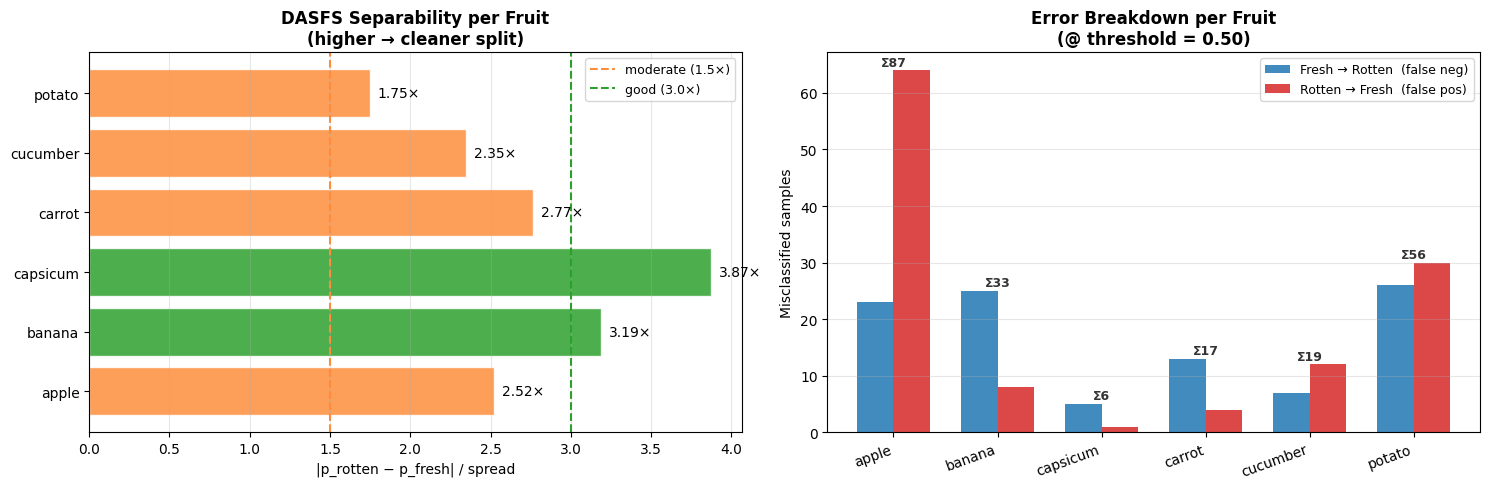

Saved -> plot_separability_errors.png


In [13]:
# ── Plot 11 — DASFS Separability + Error Breakdown ────────────────────────────
valid_dasfs = [f for f in FRUITS if f in dasfs_dict]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Separability bar ─────────────────────────────────────────────────────────
seps = []
for fruit in valid_dasfs:
    d = dasfs_dict[fruit]
    seps.append(abs(d["p_rotten"] - d["p_fresh"]) / (d["spread"] + 1e-8))

sep_colors = ["#2ca02c" if s > 3 else "#fd8d3c" if s > 1.5 else "#d62728"
              for s in seps]
bars = axes[0].barh(valid_dasfs, seps, color=sep_colors, alpha=0.85, edgecolor="white")
axes[0].axvline(1.5, color="#fd8d3c", ls="--", lw=1.5, label="moderate (1.5×)")
axes[0].axvline(3.0, color="#2ca02c", ls="--", lw=1.5, label="good (3.0×)")
for bar, sep in zip(bars, seps):
    axes[0].text(sep + 0.05, bar.get_y() + bar.get_height()/2,
                 f"{sep:.2f}×", va="center", fontsize=10)
axes[0].set_xlabel("|p_rotten − p_fresh| / spread")
axes[0].set_title("DASFS Separability per Fruit\n(higher → cleaner split)",
                  fontweight="bold")
axes[0].legend(fontsize=9); axes[0].grid(axis="x", alpha=0.3)

# ── Error breakdown (FP vs FN) ────────────────────────────────────────────────
fn_counts, fp_counts, total_errs = [], [], []
for fruit in valid_dasfs:
    mask   = ft_test == fruit
    Xf     = X_fresh_test[mask]; yt = y_test[mask]
    scores = np.array([_dasfs_score(Xf[i], fruit)[0] for i in range(len(Xf))])
    pred_f = (scores > 0.5).astype(int)
    true_f = (yt == 0).astype(int)
    fn_counts.append(((pred_f == 0) & (true_f == 1)).sum())  # fresh → rotten
    fp_counts.append(((pred_f == 1) & (true_f == 0)).sum())  # rotten → fresh
    total_errs.append((pred_f != true_f).sum())

x = np.arange(len(valid_dasfs)); w = 0.35
axes[1].bar(x - w/2, fn_counts, w, color="#1f77b4", alpha=0.85,
            label="Fresh → Rotten  (false neg)")
axes[1].bar(x + w/2, fp_counts, w, color="#d62728", alpha=0.85,
            label="Rotten → Fresh  (false pos)")
axes[1].set_xticks(x); axes[1].set_xticklabels(valid_dasfs, rotation=20, ha="right")
axes[1].set_ylabel("Misclassified samples")
axes[1].set_title("Error Breakdown per Fruit\n(@ threshold = 0.50)", fontweight="bold")
axes[1].legend(fontsize=9); axes[1].grid(axis="y", alpha=0.3)
for xi, (fn, fp, tot) in enumerate(zip(fn_counts, fp_counts, total_errs)):
    axes[1].text(xi, max(fn, fp) + 0.3, f"Σ{tot}",
                 ha="center", va="bottom", fontsize=9, color="#333", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{a}/plot_separability_errors.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved -> plot_separability_errors.png")